# Begin

In [1]:
# @launchit.collected

In [2]:
import os # @launchit.collect
import sys # @launchit.collect
import copy
from collections import namedtuple, defaultdict, Counter # @launchit.collect
import json
import datetime
import pprint
import re
import pickle
from unittest.mock import Mock
import dataclasses # @launchit.collect
from dataclasses import dataclass # @launchit.collect
import IPython
from enum import Flag, StrEnum, auto # @launchit.collect
import multiprocessing as mp
import sqlite3

import lark # @launchit.collect

from tqdm import tqdm

import numpy as np
import cupy as cp
import einops
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as pltpatches

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms.v2 as tvtv2

import optuna 
from optuna.storages import JournalStorage 
from optuna.storages.journal import JournalFileBackend 
from optuna.trial import TrialState

project_root_path = '${PROJECT_ROOT_PATH}' # @launchit.collect
# @launchit.disable
project_root_path = ! git rev-parse --show-toplevel
project_root_path = project_root_path[0]
# @launchit.stop

sys.path.append(os.path.join(project_root_path, 'lib')) # @launchit.collect
from utils import * # @launchit.collect
from math_utils import RecursiveAverageFilter
from logging_utils import *
from image_utils import *
from model_registry import *
from torch_helpers import *
from basis_pursuit import *
import launchit # @launchit.disable
import optuna_multiprocessing  # @launchit.collect
from hp_utils import *
from metrics_collector import RmqSummaryWriter
from autoincrement import Autoincrement

# Init

In [3]:
ArrayUtils.init()
LOG = Logging.get()
RNG = np.random.default_rng()
METRICS_SUITE = defaultdict(list)

class ExecMode(StrEnum):
    MASTER_NOTEBOOK = auto()
    LAUNCH_NOTEBOOK = auto()
    LAUNCH_MODULE = auto()

CONFIG = namedtuple('Config', 
                    'project_root_path, project_root_uri, model_group_uri, subproject_path, data_path, private_data_path, run_path, ' + 
                    'self_fname, self_name, ' +
                    'subproject_name,' +
                    'is_cuda, cuda_device, exec_mode, is_interactive')(
    project_root_path=project_root_path,
    project_root_uri=f'com.develorium.{os.path.basename(project_root_path)}',
    model_group_uri=None,
    subproject_path=os.path.abspath('.'),
    data_path=os.path.join(project_root_path, 'data'),
    private_data_path=None,
    run_path=None,
    self_fname=None,
    self_name=None,
    subproject_name=None,
    is_cuda=torch.cuda.is_available(),
    cuda_device='cuda' if torch.cuda.is_available() else 'cpu',
    exec_mode=ExecMode.MASTER_NOTEBOOK,
    is_interactive=True,
)

if IPython.get_ipython() is None:
    module_fname = __file__
    module_basename = os.path.basename(module_fname)
    module_name, _ = os.path.splitext(module_basename)
    
    CONFIG = CONFIG._replace(self_fname=module_fname, self_name=module_name)
    CONFIG = CONFIG._replace(exec_mode=ExecMode.LAUNCH_MODULE)
else:
    with open(IPython.get_ipython().kernel.config['IPKernelApp']['connection_file'], 'r') as cf:
        notebook_fname = json.load(cf)['jupyter_session']
        notebook_basename = os.path.basename(notebook_fname)
        notebook_name, notebook_ext = os.path.splitext(notebook_basename)
    
        m = re.match(r'(\w+)-Copy\d+$', notebook_name)
    
        if m: notebook_name = m.group(1) # e.g. Cuml is used to be launched from the copy of the notebook

        CONFIG = CONFIG._replace(self_fname=notebook_fname, self_name=notebook_name)
        
        is_launch = re.match(r'\w+-launch\d+$', notebook_name) is not None
        CONFIG = CONFIG._replace(exec_mode=ExecMode.MASTER_NOTEBOOK if not is_launch else ExecMode.LAUNCH_NOTEBOOK)

CONFIG = CONFIG._replace(is_interactive=CONFIG.exec_mode != ExecMode.LAUNCH_MODULE)

LOG.app_name = CONFIG.self_name
LOG.enable('syslog', not CONFIG.is_interactive)
LOG.enable('stdout', CONFIG.is_interactive)

CONFIG = CONFIG._replace(subproject_name=os.path.basename(os.path.dirname(CONFIG.self_fname)))
CONFIG = CONFIG._replace(model_group_uri=f'{CONFIG.project_root_uri}.{CONFIG.subproject_name}')
CONFIG = CONFIG._replace(run_path=os.path.join(project_root_path, 'run', CONFIG.subproject_name))
CONFIG = CONFIG._replace(private_data_path=os.path.join(CONFIG.data_path, CONFIG.subproject_name))
LOG(f'CONFIG=\n{pprint.pformat(CONFIG._asdict(), sort_dicts=False)}\n', when=CONFIG.is_interactive)
LOG(f'CONFIG={CONFIG._asdict()}', when=not CONFIG.is_interactive)

os.makedirs(CONFIG.private_data_path, exist_ok=True)
os.makedirs(CONFIG.run_path, exist_ok=True)

CONFIG=
{'project_root_path': '/home/misha/dev/mine/neurovision',
 'project_root_uri': 'com.develorium.neurovision',
 'model_group_uri': 'com.develorium.neurovision.16_hybrid',
 'subproject_path': '/home/misha/dev/mine/neurovision/16_hybrid',
 'data_path': '/home/misha/dev/mine/neurovision/data',
 'private_data_path': '/home/misha/dev/mine/neurovision/data/16_hybrid',
 'run_path': '/home/misha/dev/mine/neurovision/run/16_hybrid',
 'self_fname': '/home/misha/dev/mine/neurovision/16_hybrid/16e_hybrid_01.ipynb',
 'self_name': '16e_hybrid_01',
 'subproject_name': '16_hybrid',
 'is_cuda': False,
 'cuda_device': 'cpu',
 'exec_mode': <ExecMode.MASTER_NOTEBOOK: 'master_notebook'>,
 'is_interactive': True}



In [4]:
# @launchit.disable
# @launchit.collect
class LaunchGoal(StrEnum):
    UNSPECIFIED = auto()
    TRAIN_MODEL = auto()

class LaunchGoalObj(namedtuple('LaunchGoalObj', 'goal, model_group_uri, model_name, model_version, model_main_asset_fname')):
    def matches(self, *g):
        if CONFIG.exec_mode == ExecMode.MASTER_NOTEBOOK:
            return True
            
        if g and isinstance(g[0], list):
            assert len(g) == 1
            return self.goal in g[0]

        return self.goal in g

LAUNCH_GOAL = LaunchGoalObj(
    goal=LangUtils.from_str(LaunchGoal, '${LAUNCH_GOAL}', LaunchGoal.UNSPECIFIED),
    model_group_uri='${MODEL_GROUP_URI}',
    model_name='${MODEL_NAME}',
    model_version=LangUtils.from_str(int, '${MODEL_VERSION}', 0),
    model_main_asset_fname='${LAUNCHIT_FNAME}',
)
# @launchit.stop

LAUNCH_GOAL = LAUNCH_GOAL._replace(goal=LaunchGoal.UNSPECIFIED)
LAUNCH_GOAL = LAUNCH_GOAL._replace(model_group_uri=CONFIG.model_group_uri)
LAUNCH_GOAL = LAUNCH_GOAL._replace(model_name=CONFIG.self_name)
LAUNCH_GOAL = LAUNCH_GOAL._replace(model_version=0)
LAUNCH_GOAL = LAUNCH_GOAL._replace(model_main_asset_fname=CONFIG.self_fname)
# @launchit.stop

LOG(f'LAUNCH_GOAL=\n{pprint.pformat(LAUNCH_GOAL._asdict(), sort_dicts=False)}', when=CONFIG.is_interactive)
LOG(f'LAUNCH_GOAL={LAUNCH_GOAL._asdict()}', when=not CONFIG.is_interactive)

LAUNCH_GOAL=
{'goal': <LaunchGoal.UNSPECIFIED: 'unspecified'>,
 'model_group_uri': 'com.develorium.neurovision.16_hybrid',
 'model_name': '16e_hybrid_01',
 'model_version': 0,
 'model_main_asset_fname': '/home/misha/dev/mine/neurovision/16_hybrid/16e_hybrid_01.ipynb'}


# Hyperparameters

In [5]:
# @launchit.disable
# @launchit.collect
@dataclass
class Hyperparameters:
    random_seed: int = None
    # dataset params
    db_fname: str = None
    affine_transform: dict = None
    masking_levels: list = None # e.g., [0.25, 0.5, 0.75]
    masking_smootheness: int = None
    sources_mix: str = None
    # model params
    d_model: int = None # aka embedding_size
    layers_count: int = None
    heads_count: int = None
    # training params
    batch_size: int = None
    data_loader_workers_count: int = None
    epochs_count: int = None
    optimizer: str = None
    learn_rate: float | str = None
    test_batch_size: int = None

    @staticmethod
    def from_dict(d):
        hp = Hyperparameters(**d)
        return hp

    def _asdict(self):
        return dataclasses.asdict(self)

HP = Hyperparameters()
HP.random_seed = 42

# Launch

## new_model_registry

In [6]:
def new_model_registry(is_real=None):
    is_launch = CONFIG.exec_mode in [ExecMode.LAUNCH_NOTEBOOK, ExecMode.LAUNCH_MODULE]
    is_real = is_real if is_real is not None else is_launch

    if not is_real:
        mr = Mock()
        mr.register_model.return_value = 0
        return mr
        
    return ModelRegistry(LAUNCH_GOAL.model_group_uri, download_nexus_url='http://nexus-slave:8081')

## new_summary_writer

In [7]:
def new_summary_writer(log_dir, is_real=None):
    is_launch = CONFIG.exec_mode in [ExecMode.LAUNCH_NOTEBOOK, ExecMode.LAUNCH_MODULE]
    is_real = is_real if is_real is not None else is_launch

    if not is_real:
        sw = Mock()
        sw.flush.side_effect = sw.reset_mock # to get rid of all recorded call_args_list, which might be heavy (e.g. add_figure)
        return sw
    
    return RmqSummaryWriter(log_dir)

## Bootstrap

In [8]:
optuna_trial = optuna_multiprocessing.get_trial()
optuna_trial_subdir_name = ''

if optuna_trial is not None:
    optuna_trial.set_user_attr('MODEL_VERSION', LAUNCH_GOAL.model_version)
    study_serial = optuna_trial.user_attrs['STUDY_SERIAL']
    optuna_trial_subdir_name = f'opt_{study_serial}'
    LOG(f'Optuna {optuna_trial.number=}, {optuna_trial.user_attrs=}')

LOG(f'HP={HP._asdict()}', when=not CONFIG.is_interactive)
    
if HP.random_seed is not None:
    torch.manual_seed(HP.random_seed)
    RNG = np.random.default_rng(HP.random_seed)    
    LOG(f'Random seed={HP.random_seed}')

model_registry = new_model_registry()
model_registry.attach_asset(LAUNCH_GOAL.model_name, LAUNCH_GOAL.model_version, CONFIG.self_fname, replace=True)
    
meta = dict(
    optuna_trial_number=getattr(optuna_trial, 'number', None),
    hypers=HP._asdict(), 
    config=CONFIG._asdict(), 
)

with io.StringIO() as b:
    json.dump(meta, b)
    model_registry.attach_asset(LAUNCH_GOAL.model_name, LAUNCH_GOAL.model_version, b, asset_ext='json', asset_classifier='meta', replace=True)

summary_log_dir = LAUNCH_GOAL.model_name
summary_log_dir = os.path.join(summary_log_dir, optuna_trial_subdir_name) if optuna_trial_subdir_name != '' else summary_log_dir 
summary_log_dir = os.path.join(summary_log_dir, str(LAUNCH_GOAL.model_version))
LOG(f'Tensorboard run={summary_log_dir}')
summary_writer = new_summary_writer(log_dir=summary_log_dir)
summary_writer.add_text('hypers', pprint.pformat(HP._asdict(), sort_dicts=False), 1)
summary_writer.add_text('config', pprint.pformat(CONFIG._asdict(), sort_dicts=False), 1)

Random seed=42
Tensorboard run=16e_hybrid_01/0


<Mock name='mock.add_text()' id='135156273363712'>

# Dataset

## Configure

In [9]:
# @launchit.disable
# @launchit.collect
HP.db_fname = 'dataset.db'
HP.affine_transform = dict(
    degrees=(-15, 15),        # Range for rotation in degrees
    translate=(0.1, 0.1),   # Max fraction of (horizontal, vertical) translation
)
HP.masking_levels = [0.2, 0.4]
HP.masking_smootheness = 10
HP.sources_mix = dict(mnist=1, chars74k=0)
# @launchit.stop
LOG(pprint.pformat(HP._asdict(), sort_dicts=False), when=CONFIG.is_interactive)

{'random_seed': 42,
 'db_fname': 'dataset.db',
 'affine_transform': {'degrees': (-15, 15), 'translate': (0.1, 0.1)},
 'masking_levels': [0.2, 0.4],
 'masking_smootheness': 10,
 'sources_mix': {'mnist': 1, 'chars74k': 0},
 'd_model': None,
 'layers_count': None,
 'heads_count': None,
 'batch_size': None,
 'data_loader_workers_count': None,
 'epochs_count': None,
 'optimizer': None,
 'learn_rate': None,
 'test_batch_size': None}


## get_db_con

In [10]:
def get_db_con(hp=None):
    hp = LangUtils.coalesce(hp, HP)
    assert hp.db_fname, f'Uninitialized {hp.db_fname=}'
    return sqlite3.connect(f'file:{os.path.join(CONFIG.private_data_path, hp.db_fname)}?mode=ro', uri=True)

## get_image

In [11]:
def get_image(image_ind, is_test):
    table_name = ('images', 'test_images')[is_test]

    with get_db_con() as db_con:
        bts = db_con.execute(f'SELECT data FROM {table_name} WHERE ROWID=?', (image_ind,)).fetchone()[0]
        return np.load(io.BytesIO(bts))

## generate_natural_mask

In [12]:
def generate_natural_mask(size=128, masking_level=0.2, smoothness=8):
    """
    smoothness: Higher value = larger, fewer blobs. Lower = many small speckles.
    """
    # 1. Start with very low-res noise
    low_res = size // smoothness
    noise = torch.randn(1, 1, low_res, low_res)
    
    # 2. Upsample to full resolution with smoothing
    # Bilinear interpolation creates the "organic" wavy boundaries
    mask_smooth = F.interpolate(noise, size=(size, size), mode='bilinear', align_corners=False)
    
    # 3. Threshold based on the desired percentile to ensure exact coverage
    # Flatten to find the value that splits the data at the 'masking_level' point
    flat_mask = mask_smooth.view(-1).numpy()
    threshold = np.percentile(flat_mask, 100 * (1 - masking_level))

    # 4. Final binary mask (1 for masked, 0 for visible)
    binary_mask = (mask_smooth > threshold).float().numpy()[0,0]
    return binary_mask

### Unit-test

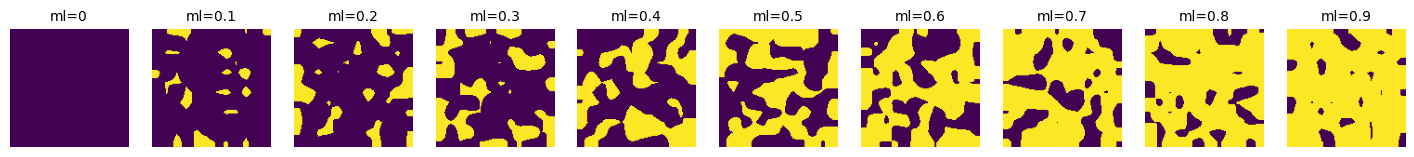

In [13]:
# @launchit.disable
masking_levels = [0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]
fig, axes = plt.subplots(1, len(masking_levels))
fig.set_figwidth(18)

for ml, ax in zip(masking_levels, axes):
    mask = generate_natural_mask(masking_level=ml, smoothness=10)
    ax.set_title(f'ml={ml}', fontdict=dict(fontsize=10))
    ax.imshow(mask)
    ax.set_axis_off()

## AugmentedDataset

In [14]:
class AugmentedDataset(Dataset):
    def __init__(self, masking_levels, sources_mix, is_test):
        self.db_con = get_db_con()
        self.image_size = self.db_con.execute('SELECT image_size FROM meta LIMIT 1').fetchone()[0]
        self.masking_levels = masking_levels
        self.is_test = is_test
        self.table_name = ('images', 'test_images')[is_test]
        source_to_image_inds = defaultdict(list)
        
        for item in self.db_con.execute(f'SELECT ROWID, source FROM {self.table_name}'):
            source_to_image_inds[item[1]].append(item[0])

        self.image_inds = []

        for source, count_percentage in sources_mix.items():
            assert 0 <= count_percentage <= 1, (source, count_percentage)
            assert source in source_to_image_inds
            count = int(len(source_to_image_inds[source]) * count_percentage)

            if count == 0:
                continue
            
            self.image_inds.extend(RNG.choice(source_to_image_inds[source], count, replace=False).tolist())

    def __del__(self):
        self.db_con.close()
    
    def __len__(self):
        return len(self.image_inds) * len(self.masking_levels)

    Item = namedtuple('Item', 'is_test, source, image_ind, masking_level, image, label, mask')

    def __getitem__(self, index):
        image_ind = self.image_inds[index // len(self.masking_levels)]
        image, label, source = self.db_con.execute(f'SELECT data, label, source FROM {self.table_name} WHERE ROWID=?', (image_ind,)).fetchone()
        image = np.load(io.BytesIO(image)).astype(np.float32)
        masking_level = self.masking_levels[index % len(self.masking_levels)]
        return AugmentedDataset.Item(
            is_test=self.is_test,
            source=source,
            image_ind=image_ind,
            masking_level=masking_level,
            image=image, 
            label=label, 
            mask=generate_natural_mask(self.image_size, masking_level, HP.masking_smootheness), 
        )

### Unit-test

In [15]:
# @launchit.disable
print(len(AugmentedDataset(HP.masking_levels, dict(mnist=1, chars74k=0), is_test=False)))
print(len(AugmentedDataset(HP.masking_levels, dict(mnist=0, chars74k=1), is_test=False)))
print(len(AugmentedDataset(HP.masking_levels, dict(mnist=0.1, chars74k=0.9), is_test=False)))
print(len(AugmentedDataset(HP.masking_levels, dict(mnist=1, chars74k=0), is_test=True)))
print(len(AugmentedDataset(HP.masking_levels, dict(mnist=0, chars74k=1), is_test=True)))
print(len(AugmentedDataset(HP.masking_levels, dict(mnist=0.1, chars74k=0.9), is_test=True)))

120000
15240
25716
20000
5080
6572


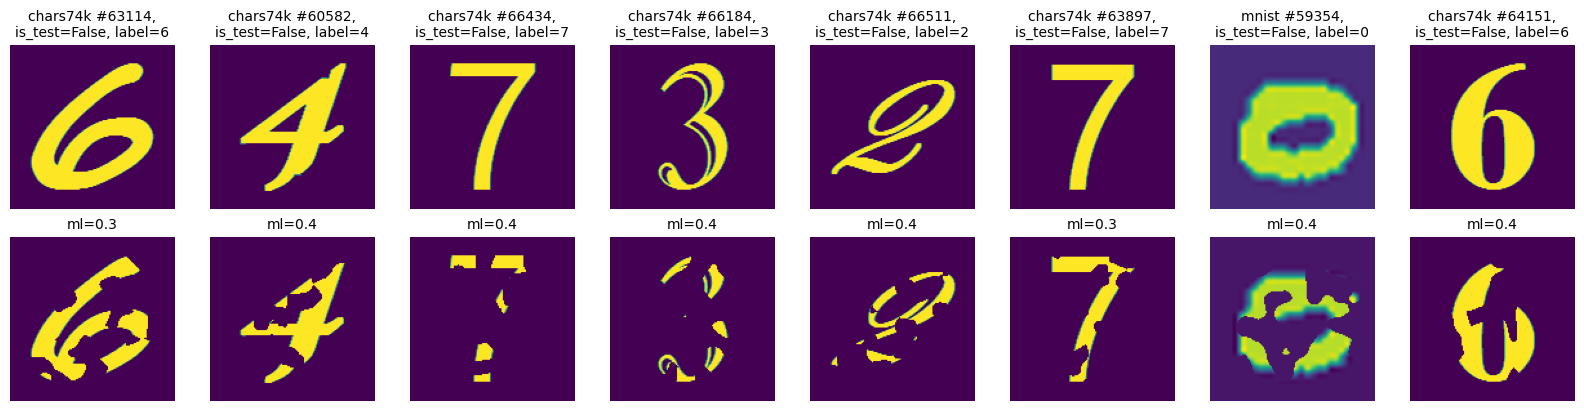

In [16]:
# @launchit.disable
ds = AugmentedDataset([0.3, 0.4], dict(mnist=0.1, chars74k=1), is_test=False)
fig, axes = plt.subplots(2, 8)
fig.set_figwidth(16)
fig.set_figheight(2 * len(axes))
fig.set_constrained_layout(True)
inds = RNG.choice(len(ds), len(axes[0]), replace=False)

for ind, ax1, ax2 in zip(inds, axes[0], axes[1]):
    item = ds[ind]
    ax1.set_title(f'{item.source} #{item.image_ind},\nis_test={item.is_test}, label={item.label}', fontdict=dict(fontsize=10))
    ax1.imshow(item.image);
    ax1.set_axis_off()
    ax2.set_title(f'ml={item.masking_level}', fontdict=dict(fontsize=10))
    ax2.imshow(item.image * (1 - item.mask));
    ax2.set_axis_off()

## AugmentedDatasetItemsCollator

In [17]:
class AugmentedDatasetItemsCollator:
    def __init__(self, affine_transform):
        self.affine_transform = affine_transform

    def __call__(self, items):
        images = torch.tensor(np.array(list(map(lambda i: i.image, items)))) # [batch,h,w]
        images = einops.rearrange(images, 'b h w -> b 1 h w') # reserve axis for just a single channel
        # affine_transforms applies THE SAME transform to all images.
        # i.e. it chooses params of transformation (assuming we are dealing with RandomTransform) 
        # and then applies these params to all images. Next batch of images - another params
        true_images = self.affine_transform(images)
        masks = torch.tensor(np.array(list(map(lambda i: i.mask, items))))
        masks = einops.rearrange(masks, 'b h w -> b 1 h w')
        masked_images = true_images * (1 - masks)
        is_test_counter = Counter(map(lambda i: i.is_test, items))
        assert len(is_test_counter) == 1 # all items must be is_test=False or is_test=True

        return dict(
            is_test=next(iter(is_test_counter.keys())),
            sources=list(map(lambda i: i.source, items)), # [batch]
            image_inds=list(map(lambda i: i.image_ind, items)), # [batch]
            labels=torch.tensor(np.array(list(map(lambda i: i.label, items)))), # [batch]
            masking_levels=list(map(lambda i: i.masking_level, items)),
            true_images=true_images, # [batch,1(channel),h,w]
            masked_images=masked_images, # [batch,1(channel),h,w]
            masks=masks, # [batch,1(channel),h,w]
        )

### Unit-test

In [18]:
# @launchit.disable
affine_transform = tvtv2.RandomAffine(**HP.affine_transform)
collator = AugmentedDatasetItemsCollator(affine_transform)

ds = AugmentedDataset([0.3, 0.4], dict(mnist=0.1, chars74k=1), is_test=False)
batch = collator(list(map(lambda i: ds[i], range(7))))

test_ds = AugmentedDataset([0.3, 0.4], dict(mnist=0.1, chars74k=1), is_test=True)
test_batch = collator(list(map(lambda i: test_ds[i], range(7))))

In [19]:
# @launchit.disable
for b in (batch, test_batch):
    for k in b.keys():
        if k == 'is_test':
            continue
        elif k in ['sources', 'image_inds', 'masking_levels']:
            left_part = f'len({k})='
            right_part = f'{len(b[k])}'
        else:
            left_part = f'{k}.shape='
            right_part = f'{b[k].shape}'

        print(f'{left_part:>30} {right_part}')
            
    assert len(b['image_inds']) == len(b['sources'])
    assert len(b['image_inds']) == b['true_images'].shape[0]
    assert b['true_images'].shape == b['masked_images'].shape
    assert b['true_images'].shape == b['masks'].shape
    assert len(b['true_images']) == len(b['labels'])

                 len(sources)= 7
              len(image_inds)= 7
                 labels.shape= torch.Size([7])
          len(masking_levels)= 7
            true_images.shape= torch.Size([7, 1, 128, 128])
          masked_images.shape= torch.Size([7, 1, 128, 128])
                  masks.shape= torch.Size([7, 1, 128, 128])
                 len(sources)= 7
              len(image_inds)= 7
                 labels.shape= torch.Size([7])
          len(masking_levels)= 7
            true_images.shape= torch.Size([7, 1, 128, 128])
          masked_images.shape= torch.Size([7, 1, 128, 128])
                  masks.shape= torch.Size([7, 1, 128, 128])


### visualize_transform_and_maskings

In [20]:
# @launchit.disable
def visualize_transform_and_maskings(affine_transform, masking_levels, is_test):
    ds = AugmentedDataset(masking_levels, dict(mnist=0.1, chars74k=1), is_test=is_test)
    collator = AugmentedDatasetItemsCollator(affine_transform)
    data_loader = DataLoader(ds, batch_size=8, collate_fn=collator, shuffle=True)
    batch = next(iter(data_loader))
    fig, axes = plt.subplots(3, len(batch))
    fig.set_figwidth(16)
    fig.set_figheight(2 * len(axes))
    fig.set_constrained_layout(True)
    
    with get_db_con() as db_con:
        for source, image_ind, ml, true_image, masked_image, label, ax1, ax2, ax3 in zip(
            batch['sources'], 
            batch['image_inds'], 
            batch['masking_levels'], 
            batch['true_images'], 
            batch['masked_images'], 
            batch['labels'], 
            axes[0], axes[1], axes[2]
        ):
            ax1.set_title(f'{source} #{image_ind}, label={label}', fontdict=dict(fontsize=10))
            ax1.imshow(get_image(image_ind, is_test));
            ax1.set_axis_off()
    
            ax2.imshow(einops.rearrange(true_image.numpy(), '1 h w -> h w'));
            ax2.set_axis_off()
            
            ax3.set_title(f'ml={ml}', fontdict=dict(fontsize=10))
            ax3.imshow(einops.rearrange(masked_image.numpy(), '1 h w -> h w'));
            ax3.set_axis_off()

    return fig

### is_test=False

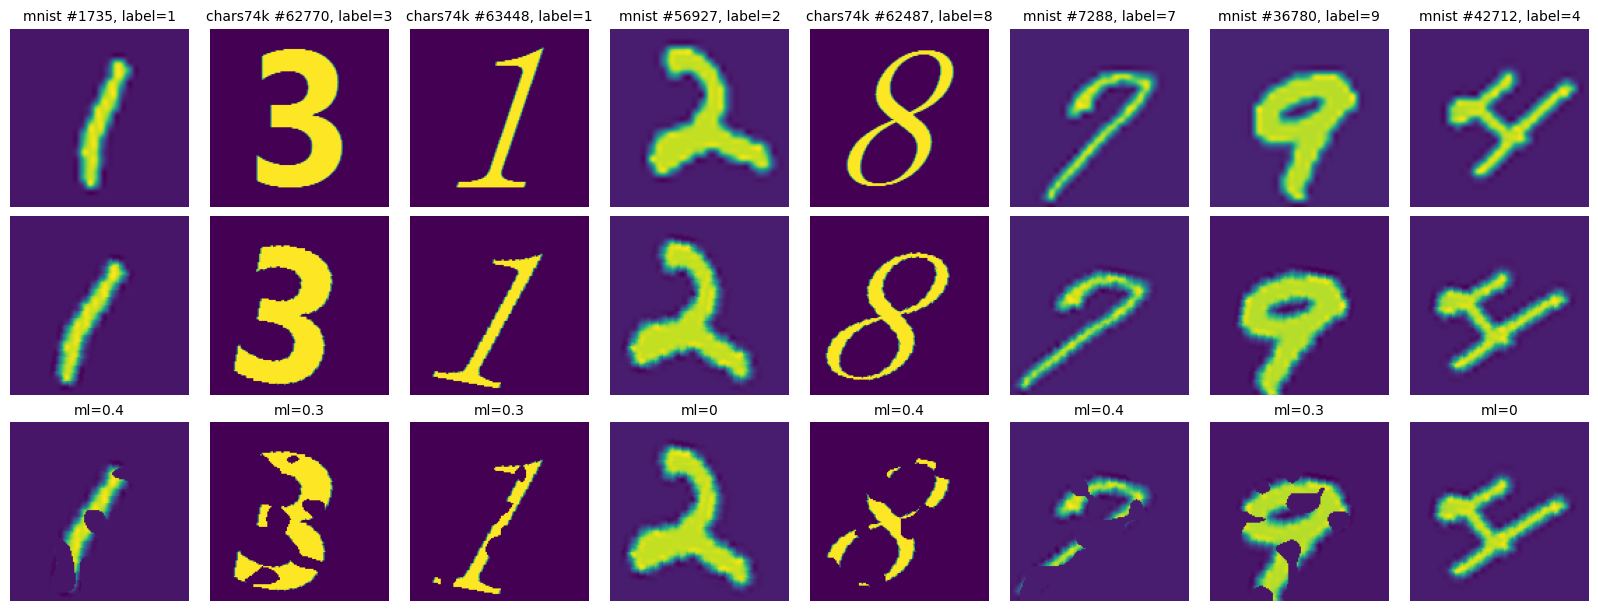

In [21]:
# @launchit.disable
affine_transform = tvtv2.RandomAffine(**dict(degrees=(-15, 15), translate=(0.1, 0.1)))
fig = visualize_transform_and_maskings(affine_transform, [0, 0.3, 0.4], is_test=False)

### is_test=True

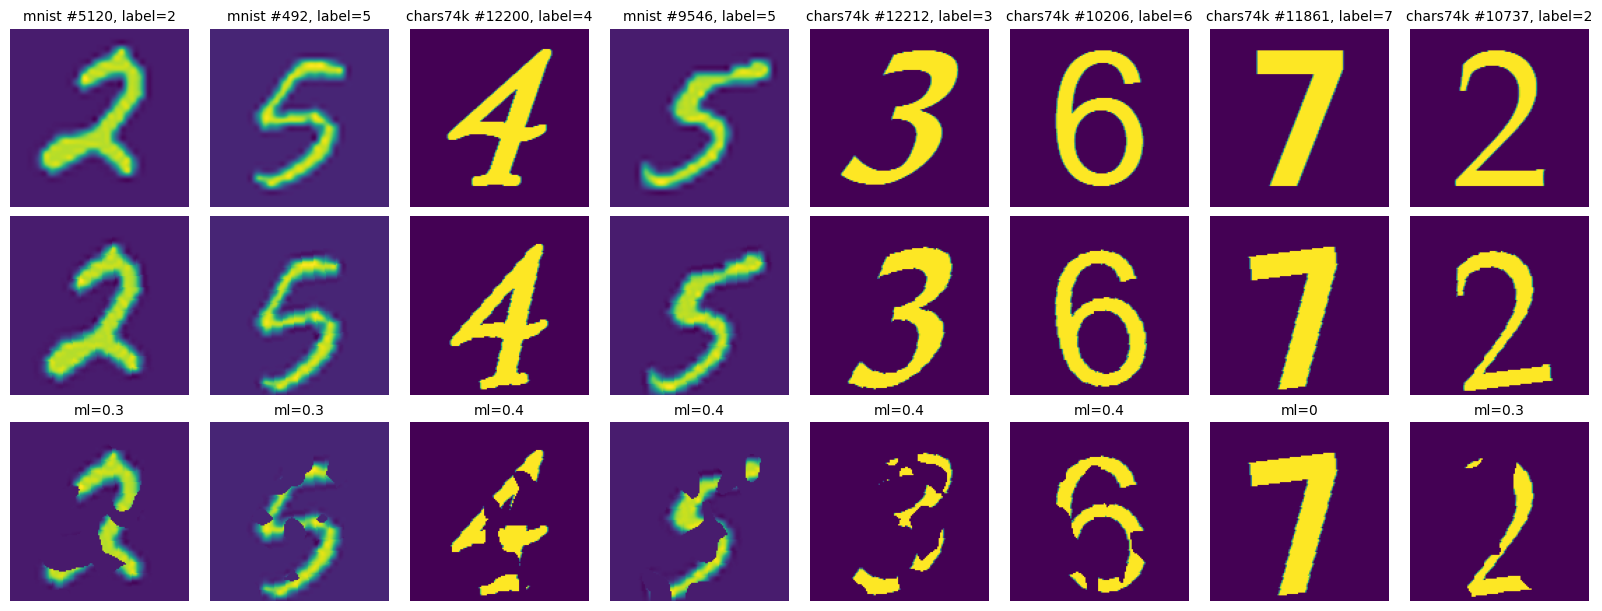

In [22]:
# @launchit.disable
affine_transform = tvtv2.RandomAffine(**dict(degrees=(-15, 15), translate=(0.1, 0.1)))
fig = visualize_transform_and_maskings(affine_transform, [0, 0.3, 0.4], is_test=True)

# Model

## HybridModel

In [23]:
class HybridModel(nn.Module):
    @dataclass 
    class Params:
        image_size: int = None
        d_model: int = None # aka embedding_size
        heads_count: int = None
        layers_count: int = None
        cls_targets_count: int = 10
        
    def __init__(self, params):
        super().__init__()
        self.params = params

        self.features_extractor = nn.Sequential(
            # Layer 1: Detect basic edges/curves (128 -> 64)
            nn.Conv2d(1, 32, kernel_size=3, stride=2, padding=1),
            nn.BatchNorm2d(32),
            nn.GELU(),
            # Layer 2: Intermediate textures (64 -> 32)
            nn.Conv2d(32, 64, kernel_size=3, stride=2, padding=1),
            nn.BatchNorm2d(64),
            nn.GELU(),
            # Layer 3: "Token" formation (32 -> 8)
            # This results in an 8x8 grid (64 tokens)
            nn.Conv2d(64, params.d_model, kernel_size=4, stride=4) 
        )

        self.reconstructor = nn.Sequential(
            # First upsample: 8x8 -> 16x16
            nn.ConvTranspose2d(params.d_model, 128, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(128),
            nn.GELU(),
            
            # Second upsample: 16x16 -> 64x64
            nn.ConvTranspose2d(128, 64, kernel_size=4, stride=4, padding=0),
            nn.BatchNorm2d(64),
            nn.GELU(),
            
            # Final reconstruction: 64x64 -> 128x128
            # The overlap here (kernel 4, stride 2) helps remove boundaries
            nn.ConvTranspose2d(64, 1, kernel_size=4, stride=2, padding=1),
            nn.Sigmoid() # Output pixels in [0, 1]
        )

        with torch.no_grad():
            probe_tensor = torch.zeros((1, 1, params.image_size, params.image_size))
            output = self.features_extractor(probe_tensor)
            output = einops.rearrange(output, '1 d h w -> 1 h w d')
            assert output.shape[1] == output.shape[2]
            self.feature_map_size = output.shape[1]
            self.seq_len = self.feature_map_size ** 2

        with torch.no_grad():
            probe_tensor = torch.zeros((1, self.seq_len, params.d_model))
            probe_tensor = einops.rearrange(probe_tensor, '1 (h w) d -> 1 d h w', h=self.feature_map_size)
            output = self.reconstructor(probe_tensor)
            shape = einops.parse_shape(output, '1 1 h w')
            assert shape['h'] == shape['w']
            assert shape['h'] == params.image_size
        
        self.cls_embedding = nn.Parameter(torch.zeros(1, 1, params.d_model)) # combined token+pos
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=params.d_model, 
            nhead=params.heads_count, 
            batch_first=True
        )
        self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=params.layers_count)
        self.classifier = nn.Linear(params.d_model, params.cls_targets_count)

    ForwardResult = namedtuple('ForwardResult', 'recon cls')

    def forward(self, masked_images):
        shape = einops.parse_shape(masked_images, 'b 1 h w')
        batch_size = shape['b']
        tvs = self.features_extractor(masked_images) # tv = thought vector
        tvs = einops.rearrange(tvs, 'b d h w -> b (h w) d')
        assert tvs.shape[1] == self.seq_len
        cls_tokens = self.cls_embedding.expand(batch_size, -1, -1) # cls_tokens shape becomes [batch, 1, d_model]
        tvs = torch.cat((cls_tokens, tvs), dim=1) # [batch, 1+seq_len, d_model]
        output = self.encoder(tvs, is_causal=False)
        cls_output = output[:,0,:] # [batch, d_model]
        main_output = output[:,1:,:] # [batch, seq_len, d_model]
        main_output = einops.rearrange(main_output, 'b (h w) d -> b d h w', h=self.feature_map_size)
        return HybridModel.ForwardResult(
            recon=self.reconstructor(main_output),
            cls=self.classifier(cls_output),
        )

## Smoke test

In [24]:
# @launchit.disable
hmp = HybridModel.Params(
    image_size=128,
    d_model=256+128,
    heads_count=16,
    layers_count=4,
)
model = HybridModel(hmp)
print(model)
params_count = sum(p.numel() for p in model.parameters())
print(f'{params_count=:_}')
probe_batch = torch.zeros((2, 1, 128, 128))
print(f'{probe_batch.shape=}')
r = model(probe_batch)
print(f'{r.recon.shape=}, {r.cls.shape=}')

HybridModel(
  (features_extractor): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): GELU(approximate='none')
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): GELU(approximate='none')
    (6): Conv2d(64, 384, kernel_size=(4, 4), stride=(4, 4))
  )
  (reconstructor): Sequential(
    (0): ConvTranspose2d(384, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): GELU(approximate='none')
    (3): ConvTranspose2d(128, 64, kernel_size=(4, 4), stride=(4, 4))
    (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): GELU(approximate='none')
    (6): ConvTranspose2d(64, 1, kernel_size=(4, 4), stride=

## visualize_model_output

In [25]:
def visualize_model_output(model, batch, device=None):
    device = LangUtils.coalesce(device, CONFIG.cuda_device)

    with eval_guard(model):
        with torch.no_grad(): 
            recon_images, cls_logits = model(batch['masked_images'].to(device))
            mse_losses = F.mse_loss(recon_images, batch['true_images'], reduction='none')
            mse_losses = einops.reduce(mse_losses, 'b 1 h w -> b', 'mean').detach().cpu().numpy()
            recon_images = recon_images.detach().cpu().numpy() # [b 1 h w]
            cls_logits = cls_logits.detach().cpu().numpy() # [b l]
            labels = np.argmax(cls_logits, axis=-1)  # [b]
    
    fig, axes = plt.subplots(4, len(batch['image_inds']))
    fig.set_figwidth(16)
    fig.set_figheight(2 * len(axes))
    fig.set_constrained_layout(True)
    
    for i, (source, image_ind, label, ml, true_image, masked_image) in enumerate(zip(
        batch['sources'], 
        batch['image_inds'], 
        batch['labels'], 
        batch['masking_levels'], 
        batch['true_images'],
        batch['masked_images']
    )):
        # Original image
        image = get_image(image_ind, is_test=batch['is_test'])
        ax = axes[0,i]
        ax.set_title(f'{source}, #{image_ind},\nis_test={batch['is_test']}, label={label.item()}', fontdict=dict(fontsize=10))
        ax.imshow(image)
        ax.set_axis_off()
    
        # True image
        ax = axes[1,i]
        ax.set_title('True', fontdict=dict(fontsize=10))
        ax.imshow(true_image[0].numpy())
        ax.set_axis_off()
    
        # Masked image
        ax = axes[2,i]
        ax.set_title(f'Masked, ml={ml}', fontdict=dict(fontsize=10))
        ax.imshow(masked_image[0].numpy())
        ax.set_axis_off()
    
        # Reconstructed image
        ax = axes[3,i]
        color = LangUtils.when(labels[i].item() == label.item(), 'g', 'r')
        ax.set_title(f'Reconstr., label={labels[i].item()}, loss={mse_losses[i].item():.2f}', fontdict=dict(fontsize=10), color=color)
        ax.imshow(recon_images[i,0])
        ax.set_axis_off()

    return fig

## test model output

In [26]:
# @launchit.disable
affine_transform = tvtv2.RandomAffine(degrees=(-15, 15),  translate=(0.1, 0.1))
collator = AugmentedDatasetItemsCollator(affine_transform)
ds = AugmentedDataset([0.2, 0.4], dict(mnist=0.1, chars74k=1), is_test=False)
test_ds = AugmentedDataset([0.2, 0.4], dict(mnist=0.5, chars74k=1), is_test=True)
batch = next(iter(DataLoader(ds, shuffle=True, batch_size=7, collate_fn=collator)))
test_batch = next(iter(DataLoader(test_ds, shuffle=True, batch_size=7, collate_fn=collator)))
hmp = HybridModel.Params(
    image_size=batch['true_images'].shape[-1],
    d_model=256+128,
    heads_count=16,
    layers_count=4,
)
model = HybridModel(hmp)
device = CONFIG.cuda_device

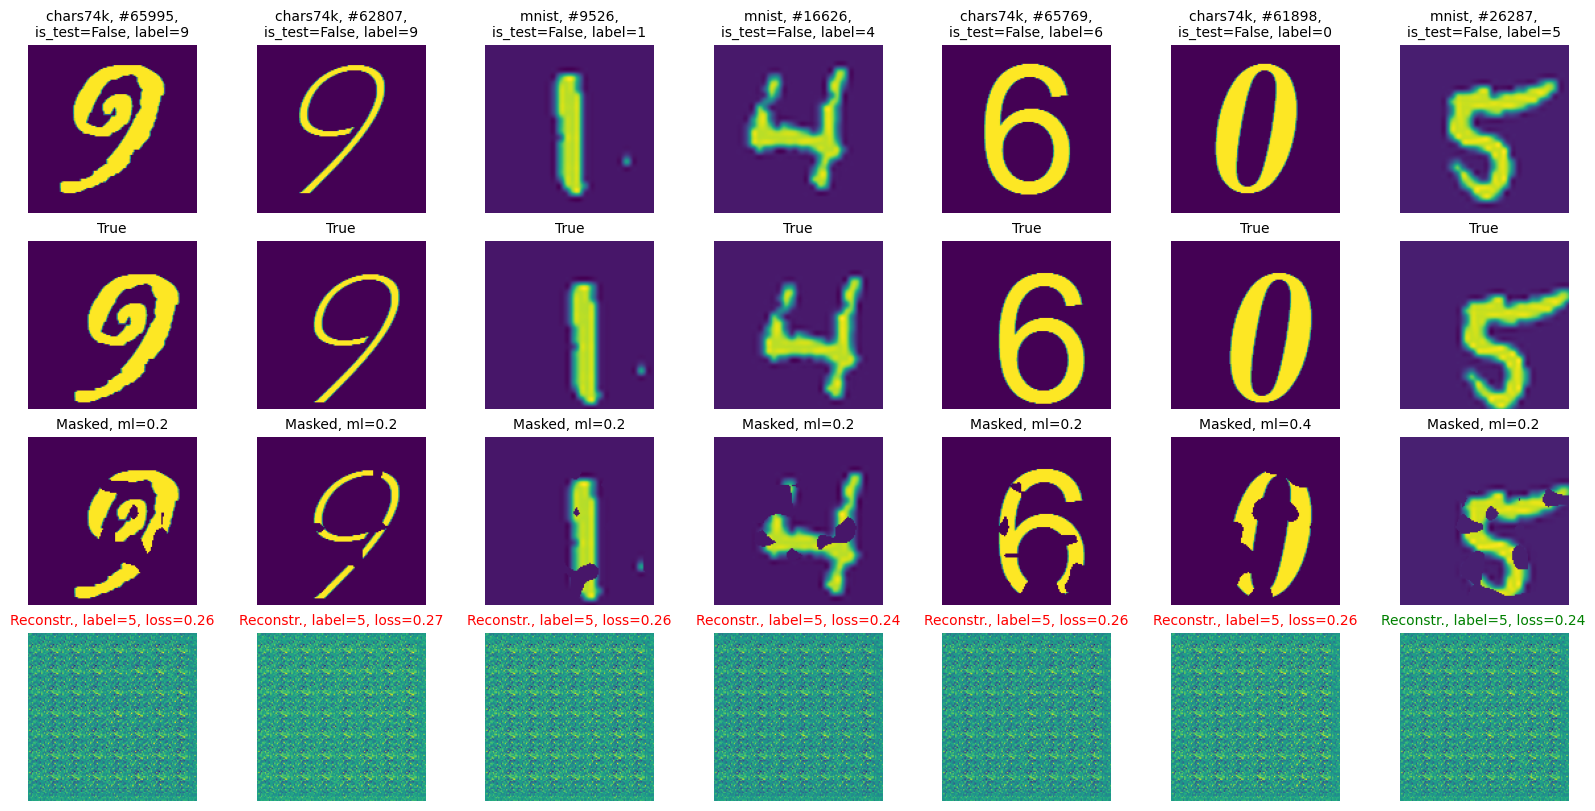

In [27]:
# @launchit.disable
fig = visualize_model_output(model, batch, device=CONFIG.cuda_device)

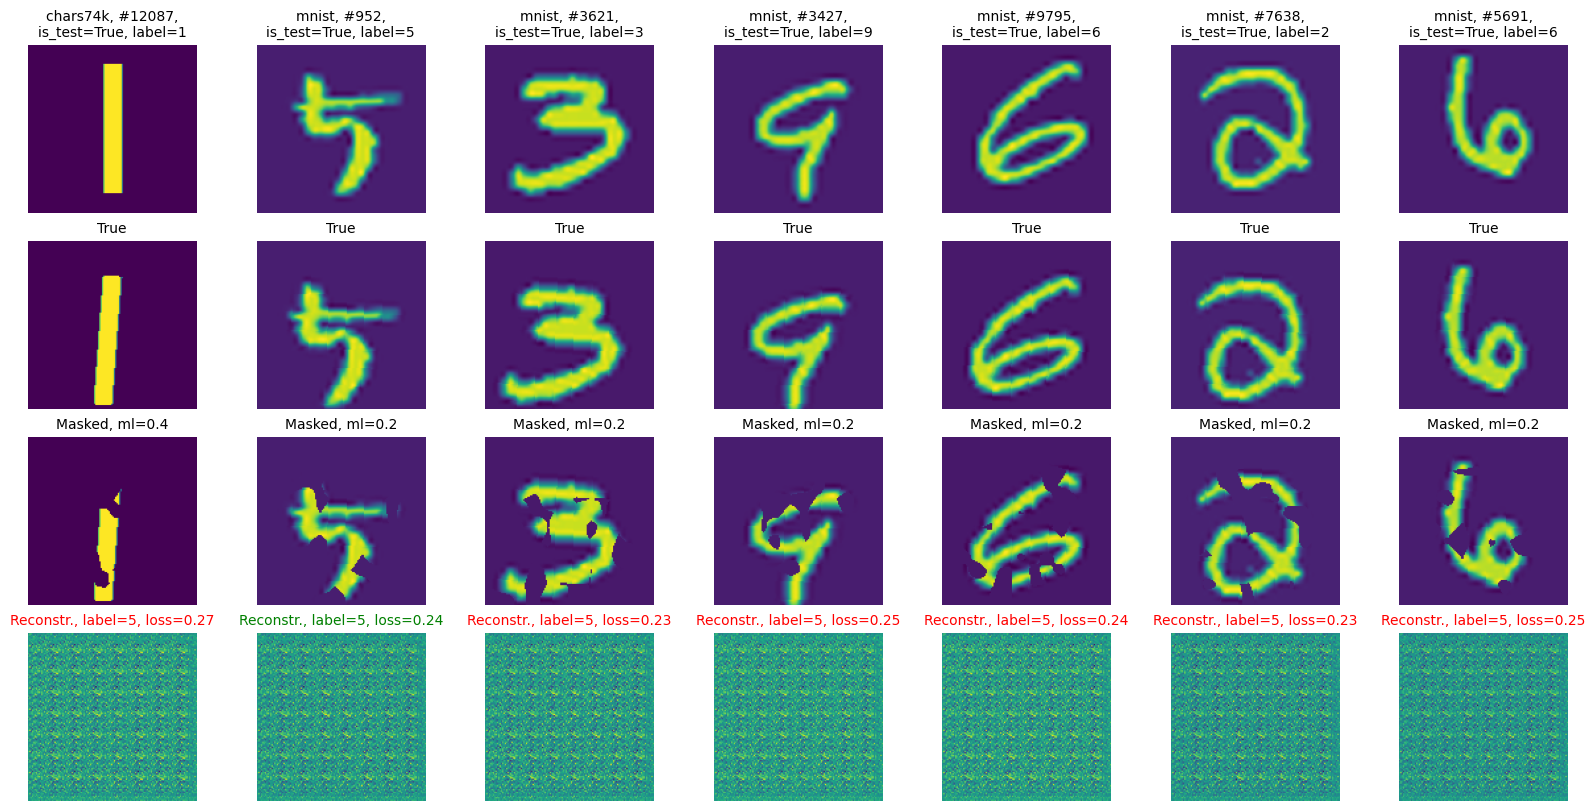

In [28]:
# @launchit.disable
fig = visualize_model_output(model, test_batch, device=CONFIG.cuda_device)

# TRAIN_MODEL

## Configure

In [29]:
# @launchit.disable
# @launchit.collect
HP.d_model = 384
HP.layers_count = 6
HP.heads_count = 16
HP.batch_size = 100
HP.data_loader_workers_count = 0
HP.epochs_count = 1
HP.optimizer = 'Adam'
HP.learn_rate = '0.0001,plateau()'
HP.test_batch_size = 1000
# @launchit.stop
LOG(pprint.pformat(HP._asdict(), sort_dicts=False), when=CONFIG.is_interactive)

{'random_seed': 42,
 'db_fname': 'dataset.db',
 'affine_transform': {'degrees': (-15, 15), 'translate': (0.1, 0.1)},
 'masking_levels': [0.2, 0.4],
 'masking_smootheness': 10,
 'sources_mix': {'mnist': 1, 'chars74k': 0},
 'd_model': 384,
 'layers_count': 6,
 'heads_count': 16,
 'batch_size': 100,
 'data_loader_workers_count': 0,
 'epochs_count': 1,
 'optimizer': 'Adam',
 'learn_rate': '0.0001,plateau()',
 'test_batch_size': 1000}


## Create

In [30]:
# @launchit.disable_2
with get_db_con() as db_con: image_size = db_con.execute('SELECT image_size FROM meta LIMIT 1').fetchone()[0]
    
hmp = HybridModel.Params(
    image_size=image_size,
    d_model=HP.d_model,
    heads_count=HP.heads_count,
    layers_count=HP.layers_count,
)
model = HybridModel(hmp)
model = model.to(CONFIG.cuda_device)
dataset = AugmentedDataset(HP.masking_levels, HP.sources_mix, is_test=False)
affine_transform = tvtv2.RandomAffine(**HP.affine_transform)
collator = AugmentedDatasetItemsCollator(affine_transform)
data_loader = DataLoader(
    dataset, 
    batch_size=HP.batch_size, 
    shuffle=True, 
    collate_fn=collator, 
    num_workers=HP.data_loader_workers_count,
    pin_memory=CONFIG.is_cuda,
)
lr_params = hp_parse_learn_rate(HP.learn_rate)
optimizer = getattr(torch.optim, HP.optimizer)(model.parameters(), lr=lr_params.learn_rate)
lr_scheduler = LrSchedulerWrapper(optimizer, lr_params)

test_dataset = AugmentedDataset(HP.masking_levels, HP.sources_mix, is_test=True)
test_batch_size = LangUtils.coalesce(HP.test_batch_size, len(test_dataset))
test_data_loader = DataLoader(test_dataset, batch_size=test_batch_size, shuffle=True, collate_fn=collator)
example_data_loader = DataLoader(test_dataset, batch_size=7, shuffle=True, collate_fn=collator)

## Train

In [31]:
# @launchit.disable_2
for epoch in tqdm(range(HP.epochs_count + 1), ncols=100, desc='Epoch', disable=not CONFIG.is_interactive):
    with LOG.auto_prefix('EPOCH', epoch):
        epoch_metrics = ('loss_all', 'loss_recon', 'loss_cls', 'accuracy', 'test_loss_all', 'test_loss_recon', 'test_loss_cls', 'test_accuracy')
        epoch_metrics = dict(map(lambda k: (k, RecursiveAverageFilter()), epoch_metrics))
    
        for batch in tqdm(data_loader, ncols=100, leave=False, desc='Batch', disable=not CONFIG.is_interactive):
            optimizer.zero_grad()

            masked_images, true_images, true_labels = tuple(map(
                lambda k: batch[k].to(CONFIG.cuda_device, non_blocking=True), 
                ('masked_images', 'true_images', 'labels')
            ))
            recon_images, cls_logits = model(masked_images)

            # LOSS OVER RECONSTRUCTION
            recon_loss = F.mse_loss(recon_images, true_images)

            # LOSS OVER CLASSIFICATION
            cls_loss = F.cross_entropy(cls_logits, true_labels)

            # OVERALL LOSS
            loss = recon_loss + cls_loss

            if epoch > 0: # first run is a dry run to get baseline for losses and other metrics
                loss.backward()
                optimizer.step()

            for k, l in zip(('loss_all', 'loss_recon', 'loss_cls'), (loss, recon_loss, cls_loss)):
                epoch_metrics[k](l.item(), batch_size=len(batch['image_inds']))

            match_map = torch.argmax(cls_logits, axis=1) == true_labels
            epoch_metrics['accuracy'](1, batch_size=(match_map == True).sum().item())
            epoch_metrics['accuracy'](0, batch_size=(match_map == False).sum().item())

        lr_scheduler.step(epoch_metrics['loss_all'].v)

        with eval_guard(model):
            with torch.no_grad(): 
                if epoch == 0:
                    test_batch = next(iter(test_data_loader))
                    test_masked_images, test_true_images, test_true_labels = tuple(map(
                        lambda k: batch[k].to(CONFIG.cuda_device, non_blocking=True), 
                        ('masked_images', 'true_images', 'labels')
                    ))

                test_recon_images, test_cls_logits = model(test_masked_images)
                test_recon_loss = F.mse_loss(test_recon_images, test_true_images)
                test_cls_loss = F.cross_entropy(test_cls_logits, test_true_labels)
                test_loss = test_recon_loss + test_cls_loss
                epoch_metrics['test_loss_all'](test_loss.item())
                epoch_metrics['test_loss_recon'](test_recon_loss.item())
                epoch_metrics['test_loss_cls'](test_cls_loss.item())
                test_match_map = torch.argmax(test_cls_logits, axis=1) == test_true_labels
                epoch_metrics['test_accuracy'](1, batch_size=(test_match_map == True).sum().item())
                epoch_metrics['test_accuracy'](0, batch_size=(test_match_map == False).sum().item())

        # Report metrics and upload figures
        concat_log = []
        
        for k, v in epoch_metrics.items():
            summary_writer.add_scalar(k, v.v, epoch)
            METRICS_SUITE[k].append(v.v)
            concat_log.append(f'{k}={v.v:.4g}')
            
        LOG(', '.join(concat_log), when=not CONFIG.is_interactive)

        if (epoch % 20) == 0 or (epoch == HP.epochs_count):
            if epoch == 0:
                example_batch = next(iter(example_data_loader))
                assert len(example_batch['image_inds']) < 10

            fig = visualize_model_output(model, example_batch, device=CONFIG.cuda_device)
            summary_writer.add_figure(f'model_output', fig, epoch, close=False) 
            plt.close(fig) # manual closing because summar_writer may be in Mock mode leaving fig unclosed
            LOG('Figure "model_output" uploaded', when=not CONFIG.is_interactive)
        
        summary_writer.flush()

        if optuna_trial is not None:
            # https://optuna.readthedocs.io/en/stable/reference/generated/optuna.trial.Trial.html#optuna.trial.Trial.report:
            # > If this method is called multiple times at the same step in a trial, the reported value only the first time is stored 
            # > and the reported values from the second time are ignored.
            # In other words calling report for fold other than the first one does nothing except producing tons of warnings in console. 
            # As such only the first fold is indicative
            optuna_trial.report(epoch_metrics['loss_all'], epoch) 
    
            if optuna_trial.should_prune():
                # Despite written in docs OPTUNA_TRIAL.should_prune is not idempotent - consequent calls could lead
                # to different responses. Perhapse this is due to influence of concurrent trials running which could change
                # pruner decision. As such cache pruning result so it's immutable
                optuna_trial.set_user_attr('IS_PRUNED', True)
                LOG(f'Optuna pruning condition encountered. Stopping training')
                break        

Epoch: 100%|██████████████████████████████████████████████████████████| 2/2 [00:10<00:00,  5.16s/it]


## Save

In [ ]:
# @launchit.disable_2
model_registry = new_model_registry()

with io.BytesIO() as b:
    torch.save(model.state_dict(), b)
    model_registry.attach_asset(LAUNCH_GOAL.model_name, LAUNCH_GOAL.model_version, b, asset_ext='pt', asset_classifier='model', replace=True)

with io.StringIO() as b:
    json.dump(dataclasses.asdict(model.params), b)
    model_registry.attach_asset(LAUNCH_GOAL.model_name, LAUNCH_GOAL.model_version, b, asset_ext='json', asset_classifier='model_params', replace=True)

## Save optuna trial result

In [36]:
# @launchit.disable_2
optuna_trial = optuna_multiprocessing.get_trial()

if optuna_trial is not None:
    if 'IS_PRUNED' in optuna_trial.user_attrs:
        raise optuna.exceptions.TrialPruned()

    if not METRICS_SUITE:
        LOG(f'Empty metrics suite. Cancelling model')
        optuna_multiprocessing.save_trial_result(0)
    else:
        match LAUNCH_GOAL.goal:
            case LaunchGoal.TRAIN_MODEL:
                last_loss_all = METRICS_SUITE['loss_all'][-1]
                optuna_multiprocessing.save_trial_result(last_loss_all)
                LOG(f'Train objective result={last_loss_all}')
            case _:
                assert False, f'Unsupported {LAUNCH_GOAL.goal=}'

# LaunchIt!

## TRAIN_MODEL

In [17]:
# @launchit.disable
launchit_t0 = time.time()

In [18]:
# @launchit.disable
launchit_interval = time.time() - launchit_t0

if launchit_interval > 0.05:
    model_version = int(Autoincrement.get(f'{LAUNCH_GOAL.model_group_uri}.{LAUNCH_GOAL.model_name}'))
    assert model_version > 0, model_version
    model_registry_obj = new_model_registry(is_real=True)
    model_registry_obj.register_model(LAUNCH_GOAL.model_name, model_version)
    LOG(f'Model instance registered, version={model_version}')
    
    expandvars = dict(
        PROJECT_ROOT_PATH=CONFIG.project_root_path,
        MODEL_GROUP_URI=LAUNCH_GOAL.model_group_uri,
        MODEL_NAME=LAUNCH_GOAL.model_name,
        MODEL_VERSION=model_version,
        LAUNCH_GOAL=LaunchGoal.TRAIN_MODEL.value,
    )
    launch_notebook_fname = launchit.launchit(CONFIG.self_fname, launch_serial=model_version, expandvars=expandvars, collect_inds=[1], disable_inds=[1])
    LOG(f'Created launch notebook "{launch_notebook_fname}"')
else:
    LOG('Skip launchit due to mass "Run Cells"')

Model instance registered, version=1
Creating /home/misha/dev/mine/neurovision/15_transformer/15f_combo_noncausal_02-launch1.ipynb
Created launch notebook "/home/misha/dev/mine/neurovision/15_transformer/15f_combo_noncausal_02-launch1.ipynb"


## Optuna (model selection)

### Templates

In [45]:
# @launchit.disable
# @launchit.collect_3
optuna_trial = optuna_multiprocessing.get_trial()

if optuna_trial is not None:
    study_serial = optuna_trial.user_attrs['STUDY_SERIAL']
    
    match study_serial:
        case 1:
            HP = Hyperparameters()
            HP.random_seed = 42
            assert False
        case _:
            assert False, f'Unsupported {study_serial=}'            

### Unleash

In [ ]:
# @launchit.disable
def get_optimize_directions(lg):
    match lg:
        case LaunchGoal.TRAIN_MODEL:
            return ['minimize']
        case _:
            assert False, f'Unsupported {lg=}'

lg = LaunchGoal.TRAIN_MODEL
expandvars = dict(
    PROJECT_ROOT_PATH=CONFIG.project_root_path,
    MODEL_GROUP_URI=LAUNCH_GOAL.model_group_uri,
    MODEL_NAME=LAUNCH_GOAL.model_name,
    LAUNCH_GOAL=lg.value,
)
study_serial = 1
study_name = f'{CONFIG.self_name}_{expandvars['LAUNCH_GOAL']}_{study_serial}'
rop_task = optuna_multiprocessing.RunOptimizationTask(
    app_name=CONFIG.self_name,
    is_stdout_enabled=False,
    notebook_fname=CONFIG.self_fname,
    notebook_name=CONFIG.self_name,
    model_group_uri=LAUNCH_GOAL.model_group_uri,
    model_name=LAUNCH_GOAL.model_name,
    expandvars=expandvars,
    collect_inds=[2],
    disable_inds=[],
    run_path=CONFIG.run_path,
    study_serial=study_serial,
    study_name=study_name,
    study_fname=os.path.join(CONFIG.run_path, study_name + '.log'),
    optimize_directions=get_optimize_directions(lg),
)
rop_tasks = [rop_task] * 1
mp_ctx = mp.get_context('spawn') # Req-d for CUDA, fork doesn't work within PyTorch

with mp_ctx.Pool(processes=4, maxtasksperchild=1) as pool:  # maxtasksperchild=1 forces fresh process for each trial to spare resources and avoid possible side effects of processe resue
    pool.map(optuna_multiprocessing.run_optimization, rop_tasks)

In [ ]:
# @launchit.disable
study = optuna.create_study(
    study_name=rop_task.study_name,
    storage=JournalStorage(JournalFileBackend(file_path=rop_task.study_fname)),
    load_if_exists=True, 
)

pruned_trials = study.get_trials(deepcopy=False, states=[TrialState.PRUNED])
complete_trials = study.get_trials(deepcopy=False, states=[TrialState.COMPLETE])

LOG('Study statistics: ')
LOG(f'\tNumber of finished trials: {len(study.trials)}')
LOG(f'\tNumber of pruned trials: {len(pruned_trials)}')
LOG(f'\tNumber of complete trials: {len(complete_trials)}')

if len(study.directions) == 1:
    LOG('Best trial:')
    trial = study.best_trial
    
    LOG(f'\tValue: {trial.value}')
    LOG(f'\tModel version: {trial.user_attrs['MODEL_VERSION']}')
    
    LOG('  Params: ')
    for key, value in trial.params.items():
        LOG(f'\t\t{key}: {value}')
else:
    print(f"Number of trials on the Pareto front: {len(study.best_trials)}")

    for i in range(3):
        print(f"Trial with lowest loss_{i}:")
        trial = min(study.best_trials, key=lambda t: t.values[i])
        print(f"\tnumber: {trial.number}")
        print(f"\tmver: {trial.user_attrs['MODEL_VERSION']}")
        print(f"\tparams: {trial.params}")
        print(f"\tvalues: {trial.values}")